# 08. 배당을 빼고 재면 "하락" 이 아닌 것이 하락이 된다 — 총수익 축을 세우다

> 2026-09-10 · 이동원 · 마이그레이션 v15 ·
> [데이터파트 명세서](../../docs/데이터파트/version4.3/명세서.md) ·
> [퀀트기준 대조 §3.2](../../docs/데이터파트/version4.2/퀀트기준_대조.md)

---

## 이 노트북이 답하는 것

> **우리 수정주가에 현금배당이 빠져 있다. 그것이 라벨을 얼마나 밀었고, 옆에 축을 세우면
> 그 밀림이 사라지는가**

세 가지를 자료로 보입니다.

1. **가격 축에서 배당락일은 눌려 있다** — 얼마나, 몇 해나
2. **총수익 축에서 그 눌림이 사라진다** — 이것이 이 작업의 검산입니다
3. **단위 오류는 크기로 자르면 안 된다** — 배당이 종가보다 큰 행 넷 중 셋이 정당했습니다

그리고 **제가 쓴 숫자가 한 번 틀렸던 것**을 그대로 적습니다.

In [1]:
import sqlite3
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

t0 = time.time()
ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from supply import total_return as TR  # noqa: E402

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)


def 한글폰트_설정() -> str:
    """한글 폰트를 잡고 깨짐을 막는다. 맑은 고딕에는 U+2212(−)가 없어서
    fallback 체인과 `axes.unicode_minus=False` 를 함께 걸어야 두부가 안 난다."""
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 □ 로 나온다.\n"
              "   Colab·Linux : !apt-get install -y fonts-nanum && fc-cache -fv (뒤에 재시작)\n"
              "   Windows     : 맑은 고딕은 기본 설치다. 캐시가 낡았으면\n"
              "                 matplotlib.font_manager._load_fontmanager(try_read_cache=False)")
        return ""
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.dpi"] = 110
    return 찾음


폰트 = 한글폰트_설정()
DB = ROOT / "data" / "krx_cache.db"
conn = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)     # 🔴 읽기 전용으로만 연다
print(f"폰트 {폰트 or '없음'} · DB {DB.stat().st_size / 1024**2:,.0f} MB · "
      f"{time.time() - t0:.1f}초")

폰트 Malgun Gothic · DB 6,677 MB · 0.5초


## 1. 무엇이 빠져 있었나

`FinanceDataReader` 로 만든 우리 `adj_close` 는 **액면분할·무상증자·주식배당까지만** 폅니다.
현금배당은 안 폅니다. 학계 표준인 CRSP 는 이 둘을 나눠서 줍니다 —

| CRSP | 뜻 | 우리 |
|---|---|---|
| `RET` | 배당 **포함** 수익률 | ❌ 없었다 |
| `RETX` | 배당 **제외** 수익률 | ✅ `adj_close` 가 이것 |

그래서 `adj_close` 를 **그대로 두고 옆에** 축을 세웠습니다. 지우고 덮는 것이 아닙니다 —
둘은 답하는 질문이 다릅니다.

```
adj_close     "분할·병합을 편 주가가 얼마였나"     (가격 축)
adj_close_tr  "배당까지 재투자하면 얼마가 됐나"    (성과 축)
```

In [2]:
r = conn.execute("""
    SELECT COUNT(*) n,
      SUM(adj_close IS NOT NULL) adj,
      SUM(adj_close_tr IS NOT NULL) tr,
      SUM(adj_dividend IS NOT NULL) div,
      SUM(is_dividend_suspect IS NOT NULL) sus
    FROM daily_price
""").fetchone()
print(f"daily_price {r[0]:,}행")
print(f"  수정종가 {r[1]:,} ({r[1] / r[0] * 100:.2f}%)")
print(f"  총수익   {r[2]:,} ({r[2] / r[0] * 100:.2f}%)")
print(f"  배당이 얹힌 행 {r[3]:,} · 단위 오류로 뺀 행 {r[4]:,}")
print()
print(f"총수익이 빈 행 {r[0] - r[2]:,} = 수정종가가 빈 행 {r[0] - r[1]:,}")
print("  → 수정주가를 아직 안 채운 최근 3거래일(2026-09-02~04)이다. "
      f"{'✅ 같다' if r[0] - r[2] == r[0] - r[1] else '🔴 다르다'}")

daily_price 9,231,938행
  수정종가 9,223,800 (99.91%)
  총수익   9,223,800 (99.91%)
  배당이 얹힌 행 20,243 · 단위 오류로 뺀 행 1

총수익이 빈 행 8,138 = 수정종가가 빈 행 8,138
  → 수정주가를 아직 안 채운 최근 3거래일(2026-09-02~04)이다. ✅ 같다


## 2. 조인 축은 배당락일이지 기준일이 아니다

포털이 주는 것은 **배당기준일**(`dvdn_bas_dt`)인데 12월 결산법인이면 12월 31일이고
**그날은 휴장**입니다. 값이 실제로 움직이는 날은 **배당락일**이고, 결제(T+2) 때문에
기준일에서 거래일 두 걸음 앞입니다.

이것이 왜 중요한지 숫자로 보겠습니다.

In [3]:
q = """
SELECT substr(dvdn_bas_dt,1,2) || '월' AS 월,
       COUNT(*) AS 건수,
       SUM(dvdn_bas_dt IN (SELECT DISTINCT bas_dd FROM trading_calendar)) AS 거래일
FROM dividend
WHERE dvdn_bas_dt >= '20100101' AND dvdn_rcd_nm IN ('현금배당','동시배당')
GROUP BY substr(dvdn_bas_dt,5,2)
ORDER BY substr(dvdn_bas_dt,5,2)
"""
# 월을 제대로 뽑는다 — YYYYMMDD 의 5~6번째가 월이다
q = q.replace("substr(dvdn_bas_dt,1,2)", "substr(dvdn_bas_dt,5,2)")
월별 = pd.read_sql_query(q, conn)
월별["거래일비율%"] = 월별["거래일"] / 월별["건수"] * 100
print("배당기준일이 실제로 거래일인가 (2010~ 현금·동시배당)")
print(월별.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
전체 = 월별["건수"].sum()
전체거래일 = 월별["거래일"].sum()
print(f"\n전체 {전체:,}건 중 거래일 {전체거래일:,}건 ({전체거래일 / 전체 * 100:.1f}%)")
십이월 = 월별[월별["월"] == "12월"]
if not 십이월.empty:
    v = 십이월.iloc[0]
    print(f"🔴 12월만 보면 {v['건수']:,.0f}건 중 거래일 {v['거래일']:,.0f}건 "
          f"({v['거래일비율%']:.1f}%) — 기준일로 조인하면 대부분이 허공에 붙는다")

배당기준일이 실제로 거래일인가 (2010~ 현금·동시배당)
  월    건수  거래일  거래일비율%
01월   154  119    77.3
02월   303  254    83.8
03월  1431 1142    79.8
04월   338  302    89.3
05월   232  162    69.8
06월  1421 1015    71.4
07월   211  193    91.5
08월   312  254    81.4
09월   577  390    67.6
10월   183  148    80.9
11월   217  144    66.4
12월 20366   67     0.3

전체 25,745건 중 거래일 4,190건 (16.3%)
🔴 12월만 보면 20,366건 중 거래일 67건 (0.3%) — 기준일로 조인하면 대부분이 허공에 붙는다


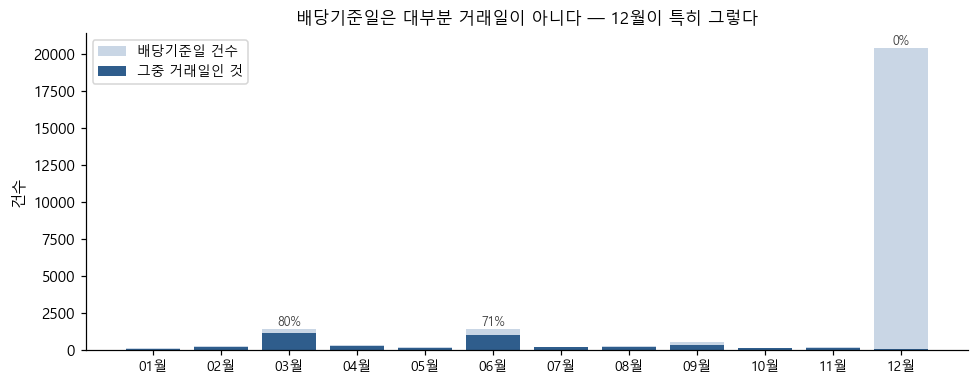

막대 위 숫자는 그 달 기준일 중 거래일 비율이다.


In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(월별))
ax.bar(x, 월별["건수"], color="#c9d6e5", label="배당기준일 건수")
ax.bar(x, 월별["거래일"], color="#2f5d8c", label="그중 거래일인 것")
ax.set_xticks(x)
ax.set_xticklabels(월별["월"], fontsize=9)
ax.set_ylabel("건수")
ax.set_title("배당기준일은 대부분 거래일이 아니다 — 12월이 특히 그렇다", fontsize=11)
ax.legend(fontsize=9)
for i, row in 월별.reset_index(drop=True).iterrows():
    if row["건수"] > 전체 * 0.05:
        ax.text(i, row["건수"], f"{row['거래일비율%']:.0f}%", ha="center",
                va="bottom", fontsize=8, color="#444")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("막대 위 숫자는 그 달 기준일 중 거래일 비율이다.")

## 3. 🔴 가격 축에서 배당락일은 눌려 있다

이제 본 질문입니다. 배당락일의 일간수익률을 평소와 비교합니다.

**개발구간(~2024-08-31)** 만 봅니다 — 홀드아웃은 봉인되어 있습니다.

In [5]:
px = pd.read_sql_query("""
    SELECT bas_dd, code, adj_close, adj_close_tr, adj_dividend
    FROM daily_price
    WHERE bas_dd <= '20240831' AND adj_close IS NOT NULL AND adj_close_tr IS NOT NULL
    ORDER BY code, bas_dd
""", conn)
print(f"{len(px):,}행 · {px['code'].nunique():,}종목 · {time.time() - t0:.0f}초")

px["가격수익률"] = px.groupby("code")["adj_close"].pct_change()
px["총수익수익률"] = px.groupby("code")["adj_close_tr"].pct_change()
px = px.dropna(subset=["가격수익률", "총수익수익률"])
배당일 = px["adj_dividend"].notna()
print(f"배당락일 {int(배당일.sum()):,}행 · 그 외 {int((~배당일).sum()):,}행")

표 = []
for 축 in ("가격수익률", "총수익수익률"):
    표.append({
        "축": "가격 adj_close" if 축 == "가격수익률" else "총수익 adj_close_tr",
        "배당락일%": px.loc[배당일, 축].mean() * 100,
        "평소%": px.loc[~배당일, 축].mean() * 100,
        "차이%p": (px.loc[배당일, 축].mean() - px.loc[~배당일, 축].mean()) * 100,
    })
결과 = pd.DataFrame(표)
print()
print(결과.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

7,888,945행 · 3,462종목 · 97초


배당락일 17,041행 · 그 외 7,868,442행



               축   배당락일%     평소%    차이%p
    가격 adj_close -0.2595 +0.8870 -1.1465
총수익 adj_close_tr +2.2106 +0.8870 +1.3235


**차이의 부호가 뒤집혔습니다.** 가격 축에서는 배당락일이 평소보다 낮고, 총수익 축에서는
높습니다. 높아지는 것이 맞습니다 — 배당락일에 가격은 배당만큼 떨어지지만 **주주는 그 배당을
받았기** 때문입니다. 총수익 축은 그것을 되돌려 놓습니다.

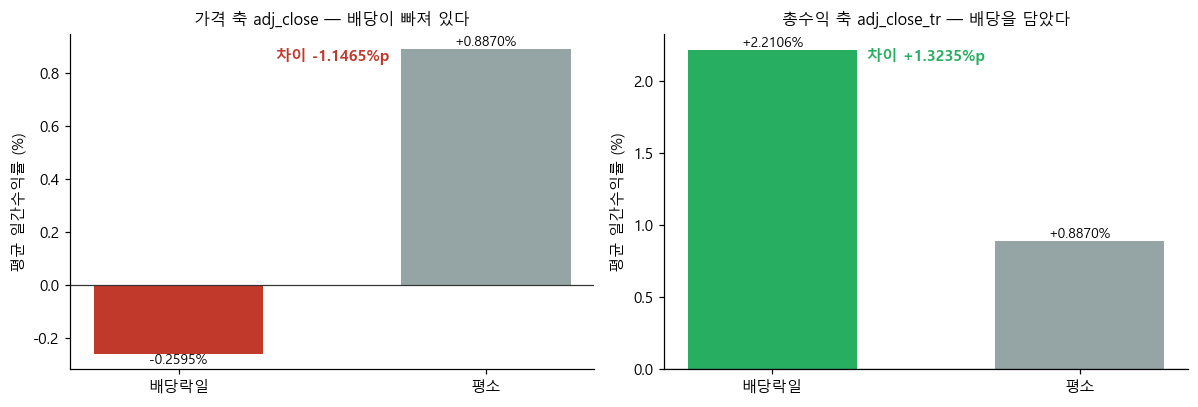

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, 축, 제목 in zip(
        axes, ("가격수익률", "총수익수익률"),
        ("가격 축 adj_close — 배당이 빠져 있다", "총수익 축 adj_close_tr — 배당을 담았다"),
        strict=True):
    배당값 = px.loc[배당일, 축].mean() * 100
    평소값 = px.loc[~배당일, 축].mean() * 100
    색 = ["#c0392b" if 배당값 < 평소값 else "#27ae60", "#95a5a6"]
    ax.bar(["배당락일", "평소"], [배당값, 평소값], color=색, width=0.55)
    ax.axhline(0, color="#333", lw=0.8)
    ax.set_ylabel("평균 일간수익률 (%)")
    ax.set_title(제목, fontsize=10.5)
    for i, v in enumerate([배당값, 평소값]):
        ax.text(i, v, f"{v:+.4f}%", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=9)
    ax.text(0.5, 0.92, f"차이 {배당값 - 평소값:+.4f}%p", transform=ax.transAxes,
            ha="center", fontsize=10, weight="bold",
            color="#c0392b" if 배당값 < 평소값 else "#27ae60")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. 몇 해나 눌렸나 — 연도별로 본다

평균 하나로는 "몇 번 그랬나" 를 알 수 없습니다. 해마다 나눠 봅니다.

In [7]:
px["연도"] = px["bas_dd"].str[:4]
연도표 = []
for yr, g in px.groupby("연도"):
    d = g["adj_dividend"].notna()
    if d.sum() < 30:
        continue
    연도표.append({
        "연도": yr, "배당락일수": int(d.sum()),
        "가격차%p": (g.loc[d, "가격수익률"].mean() - g.loc[~d, "가격수익률"].mean()) * 100,
        "총수익차%p": (g.loc[d, "총수익수익률"].mean()
                   - g.loc[~d, "총수익수익률"].mean()) * 100,
    })
연도표 = pd.DataFrame(연도표)
print(연도표.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
가음 = int((연도표["가격차%p"] < 0).sum())
총음 = int((연도표["총수익차%p"] < 0).sum())
연도수 = len(연도표)   # 🔴 `n` 으로 두면 §6 의 대상 행 수가 덮어쓴다
print(f"\n가격 축이 음수인 해   {가음}/{연도수}")
print(f"총수익 축이 음수인 해 {총음}/{연도수}")

  연도  배당락일수    가격차%p   총수익차%p
2010   1055  -0.0732  +2.1569
2011   1061  -0.7065  +1.6468
2012   1050  -0.2130  +1.9195
2013   1048 -13.9397 -12.0348
2014   1081  -0.6622  +1.0932
2015   1107  +0.2108  +1.9263
2016   1162  -0.0768  +1.6353
2017   1228  +0.0603  +1.8234
2018   1270  +0.1927  +2.2177
2019   1278  -0.2039  +1.7795
2020   1277  +0.4814  +2.4554
2021   1368  -0.3472  +1.5247
2022   1424  -1.3773  +6.2242
2023   1334  -1.0674  +1.4545
2024    298  -1.5695  +0.7079

가격 축이 음수인 해   11/15
총수익 축이 음수인 해 1/15


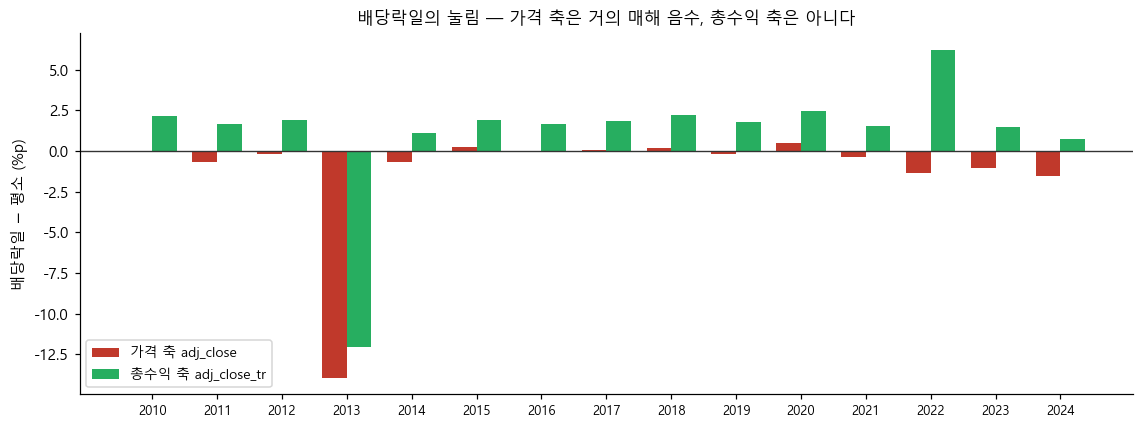

2013년만 총수익 축에서도 음수다. 그 해에 배당락일과 겹친 큰 하락이 따로 있었다는
뜻이고, 배당으로는 설명되지 않는다 — 그래서 총수익 축에서도 남는다.


In [8]:
fig, ax = plt.subplots(figsize=(10.5, 4))
x = np.arange(len(연도표))
w = 0.38
ax.bar(x - w / 2, 연도표["가격차%p"], w, label="가격 축 adj_close", color="#c0392b")
ax.bar(x + w / 2, 연도표["총수익차%p"], w, label="총수익 축 adj_close_tr",
       color="#27ae60")
ax.axhline(0, color="#333", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(연도표["연도"], rotation=0, fontsize=8.5)
ax.set_ylabel("배당락일 − 평소 (%p)")
ax.set_title("배당락일의 눌림 — 가격 축은 거의 매해 음수, 총수익 축은 아니다", fontsize=11)
ax.legend(fontsize=9, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("2013년만 총수익 축에서도 음수다. 그 해에 배당락일과 겹친 큰 하락이 따로 있었다는")
print("뜻이고, 배당으로는 설명되지 않는다 — 그래서 총수익 축에서도 남는다.")

## 5. 왜 라벨이 밀리나 — 중립대 ±2% 와 견줘 본다

우리 개별종목 라벨은 **절대 밴드 ±2%** 입니다
([ADR 0006 개별종목 중립대와 평가기준선](../../docs/decisions/0006-개별종목-중립대와-평가기준선.md)). 5거래일 창에 배당락일이 들어오면
그 창의 수익률이 배당만큼 아래로 밀립니다. 밴드에 견줘 얼마나 큰지 봅니다.

In [9]:
밴드 = 2.0
눌림 = abs(연도표["가격차%p"].mean())
print(f"배당락일 평균 눌림     {눌림:.4f}%p")
print(f"개별종목 중립대 폭     ±{밴드:.1f}%  (전체 폭 {밴드 * 2:.1f}%p)")
print(f"→ 눌림이 밴드 전체 폭의 {눌림 / (밴드 * 2) * 100:.1f}% 를 차지한다")
print()
# 배당수익률 분포 — 얹힌 배당이 얼마나 큰가
얹힘 = pd.read_sql_query("""
    SELECT adj_dividend, adj_close, adj_dividend / adj_close * 100 AS 배당수익률
    FROM daily_price
    WHERE adj_dividend IS NOT NULL AND adj_close > 0 AND bas_dd <= '20240831'
""", conn)
print(f"얹힌 배당 {len(얹힘):,}건의 배당수익률 분위")
for p in (50, 75, 90, 95, 99):
    print(f"  p{p:<3} {얹힘['배당수익률'].quantile(p / 100):>7.3f}%")
print(f"  최대  {얹힘['배당수익률'].max():>7.3f}%")
넘음 = int((얹힘["배당수익률"] > 밴드).sum())
print(f"\n배당 하나가 중립대 절반(±{밴드}%)을 넘는 건수 "
      f"{넘음:,} ({넘음 / len(얹힘) * 100:.1f}%)")

배당락일 평균 눌림     1.2861%p
개별종목 중립대 폭     ±2.0%  (전체 폭 4.0%p)
→ 눌림이 밴드 전체 폭의 32.2% 를 차지한다



얹힌 배당 17,044건의 배당수익률 분위
  p50    1.586%
  p75    2.688%
  p90    4.103%
  p95    5.141%
  p99    7.651%
  최대  5964.286%

배당 하나가 중립대 절반(±2.0%)을 넘는 건수 6,608 (38.8%)


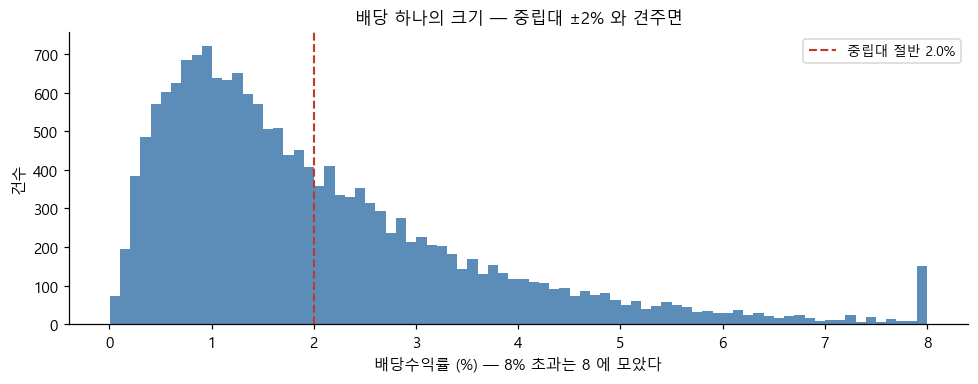

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))
값 = 얹힘["배당수익률"].clip(upper=8)
ax.hist(값, bins=80, color="#5b8db8", edgecolor="none")
ax.axvline(밴드, color="#c0392b", lw=1.4, ls="--",
           label=f"중립대 절반 {밴드}%")
ax.set_xlabel("배당수익률 (%) — 8% 초과는 8 에 모았다")
ax.set_ylabel("건수")
ax.set_title("배당 하나의 크기 — 중립대 ±2% 와 견주면", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. 🔴 단위 오류는 크기로 자르면 안 된다

원본에 **주당 18.5억원** 이라는 배당이 있습니다(윙입푸드홀딩스 2018-12-27). 명백한 오류라
빼야 하는데, **"크면 뺀다"** 로 규칙을 세우면 안 됩니다.

배당이 종가보다 큰 행을 전수로 봅니다.

In [11]:
큰것 = pd.read_sql_query("""
    SELECT d.code, d.corp_nm, d.ex_date,
           COALESCE(NULLIF(d.genr_dvdn_amt,0), d.grdn_dvdn_amt) AS 금액,
           d.genr_cash_dvdn_rt AS 배당률, d.par_price_at_load AS 적재액면,
           p.close AS 종가
    FROM dividend d JOIN daily_price p ON p.code=d.code AND p.bas_dd=d.ex_date
    WHERE d.ex_date >= '20100104' AND d.dvdn_rcd_nm IN ('현금배당','동시배당')
      AND p.close > 0
      AND COALESCE(NULLIF(d.genr_dvdn_amt,0), d.grdn_dvdn_amt) > p.close
    ORDER BY 금액 / 종가 DESC
""", conn)
큰것["배당수익률%"] = 큰것["금액"] / 큰것["종가"] * 100
큰것["역산액면"] = [TR.implied_par_price(a, r)
              for a, r in zip(큰것["금액"], 큰것["배당률"], strict=True)]
큰것["의심"] = [TR.is_suspect(a, r, c, p) for a, r, c, p
             in zip(큰것["금액"], 큰것["배당률"], 큰것["종가"], 큰것["적재액면"],
                    strict=True)]
print(f"배당이 종가보다 큰 행 — 전수 {len(큰것)}건")
print(큰것[["code", "corp_nm", "ex_date", "금액", "종가", "배당수익률%",
          "배당률", "역산액면", "의심"]].to_string(index=False))

배당이 종가보다 큰 행 — 전수 4건
  code                           corp_nm  ex_date           금액   종가       배당수익률%         배당률   역산액면    의심
900340                           윙입푸드홀딩스 20181227 1851481913.0 1395 1.327227e+08    0.000000    NaN  True
152550 한국투자ANKOR유전해외자원개발특별자산투자회사1호(지분증권) 20221214       1670.0   28 5.964286e+03   56.210030 2971.0 False
417310                  코람코더원위탁관리부동산투자회사 20260828       8900.0 2335 3.811563e+02 1780.000000  500.0 False
168490     한국투자패러랠유전해외자원개발특별자산투자회사1호지분증권 20231227       1342.0  481 2.790021e+02   52.136752 2574.0 False


**넷 중 셋이 정당합니다.**

| 행 | 정체 | 되짚은 액면가 |
|---|---|---|
| 윙입푸드홀딩스 | 배당률도 액면가도 0 — 되짚을 수 없다 | ❌ **오류** |
| 한국투자ANKOR | 유전펀드 청산분배 (종가 28원에 1,670원) | 되짚힌다 |
| 코람코더원 | 리츠 분배 | 액면 500 에 정확히 붙는다 |
| 한국투자패러랠 | 유전펀드 분배 | 되짚힌다 |

크기로 자르면 **정당한 청산분배금 셋이 함께 잘려** 총수익이 아래로 편향됩니다. 이것이
표준이 말하는 것과 같습니다 — winsorize·truncate 는 극단값이 **데이터 오류**일 때 타당하고,
**데이터 생성 과정**에서 나온 것에 적용하면 편향을 만듭니다(Leone et al.).

### 그래서 무엇으로 가르나 — 원본이 자기 정합적인가

`genr_cash_dvdn_rt` 는 시가배당률이 아니라 **액면가 대비 배당률**입니다. 금액을 그 비율로
나누면 **그날의 액면가**가 되짚어집니다.

In [12]:
for 이름, 금액, 배당률 in [("현대차", 2500.0, 50.0), ("SK하이닉스", 375.0, 7.5),
                          ("코오롱글로벌", 200.0, 4.0), ("동원산업", 600.0, 60.0)]:
    print(f"  {이름:<12} 배당 {금액:>7,.0f}원 ÷ ({배당률}%/100) = "
          f"액면 {TR.implied_par_price(금액, 배당률):>8,.0f}원")
print()
print("🔴 `dividend.par_price_at_load` 로는 이 일을 못 한다 — 그 칸은 **적재 시점**의")
print("   액면가라 삼성전자 1987년 배당 행에도 100원(2018년 분할 뒤 값)이 들어 있다.")
print()
샘플 = pd.read_sql_query("""
    SELECT code, corp_nm, dvdn_bas_dt, genr_dvdn_amt, genr_cash_dvdn_rt,
           par_price_at_load
    FROM dividend WHERE code='005930' AND genr_dvdn_amt > 0
    ORDER BY dvdn_bas_dt LIMIT 3
""", conn)
샘플["역산액면"] = [TR.implied_par_price(a, r) for a, r
                in zip(샘플["genr_dvdn_amt"], 샘플["genr_cash_dvdn_rt"],
                       strict=True)]
print("삼성전자 옛 배당 — 적재 액면가는 100원인데 되짚은 값은 그때 액면가다")
print(샘플.to_string(index=False))

  현대차          배당   2,500원 ÷ (50.0%/100) = 액면    5,000원
  SK하이닉스       배당     375원 ÷ (7.5%/100) = 액면    5,000원
  코오롱글로벌       배당     200원 ÷ (4.0%/100) = 액면    5,000원
  동원산업         배당     600원 ÷ (60.0%/100) = 액면    1,000원

🔴 `dividend.par_price_at_load` 로는 이 일을 못 한다 — 그 칸은 **적재 시점**의
   액면가라 삼성전자 1987년 배당 행에도 100원(2018년 분할 뒤 값)이 들어 있다.

삼성전자 옛 배당 — 적재 액면가는 100원인데 되짚은 값은 그때 액면가다
  code corp_nm dvdn_bas_dt  genr_dvdn_amt  genr_cash_dvdn_rt  par_price_at_load   역산액면
005930    삼성전자    20030630          500.0               10.0              100.0 5000.0
005930    삼성전자    20031231         5000.0              100.0              100.0 5000.0
005930    삼성전자    20040630         5000.0              100.0              100.0 5000.0


In [13]:
# 전 구간에 그 자를 대 본다
대상 = pd.read_sql_query("""
    SELECT d.code, d.corp_nm, d.ex_date,
           d.genr_dvdn_amt AS genr, d.grdn_dvdn_amt AS grdn,
           d.genr_cash_dvdn_rt AS 배당률, d.par_price_at_load AS 적재액면,
           p.close AS 종가
    FROM dividend d JOIN daily_price p ON p.code=d.code AND p.bas_dd=d.ex_date
    WHERE d.ex_date >= '20100104' AND d.dvdn_rcd_nm IN ('현금배당','동시배당')
      AND (d.genr_dvdn_amt > 0 OR d.grdn_dvdn_amt > 0)
""", conn)
대상["금액"] = [TR.dividend_amount(g, r)
            for g, r in zip(대상["genr"], 대상["grdn"], strict=True)]
대상["정합"] = [TR.is_par_consistent(a, r, p) for a, r, p
              in zip(대상["금액"], 대상["배당률"], 대상["적재액면"],
                     strict=True)]
대상수 = len(대상)
맞음 = int((대상["정합"] == True).sum())          # noqa: E712 — None 과 갈라야 한다
틀림 = int((대상["정합"] == False).sum())         # noqa: E712
모름 = int(대상["정합"].isna().sum())
print(f"조인되는 {대상수:,}행을 세 갈래로")
print(f"  ① 되짚어 표준·적재 액면가에 붙는다  {맞음:>6,} ({맞음 / 대상수 * 100:5.2f}%)  → 믿는다")
print(f"  ② 되짚히는데 어디에도 안 붙는다      {틀림:>6,} ({틀림 / 대상수 * 100:5.2f}%)")
print(f"  ③ 배당률이 없어 되짚을 수 없다        {모름:>6,} ({모름 / 대상수 * 100:5.2f}%)")
print()
print("② 를 회사별로 묶어 보면 — 전부 정당한 갈래다")
g2 = 대상[대상["정합"] == False].groupby("corp_nm").size().sort_values(  # noqa: E712
    ascending=False)
for nm, c in g2.items():
    print(f"    {nm[:44]:<44} {c:>3}행")

조인되는 20,248행을 세 갈래로
  ① 되짚어 표준·적재 액면가에 붙는다  20,104 (99.29%)  → 믿는다
  ② 되짚히는데 어디에도 안 붙는다         111 ( 0.55%)
  ③ 배당률이 없어 되짚을 수 없다            33 ( 0.16%)

② 를 회사별로 묶어 보면 — 전부 정당한 갈래다
    한국투자패러랠유전해외자원개발특별자산투자회사1호지분증권                 42행
    한국투자ANKOR유전해외자원개발특별자산투자회사1호(지분증권)             38행
    맥쿼리한국인프라투융자회사                                 24행
    잉글우드랩 KDR                                      2행
    케이비발해인프라투융자회사                                  2행
    마스턴프리미어제1호위탁관리부동산투자회사                          1행
    차이나크리스탈신소재홀딩스                                  1행
    코람코더원위탁관리부동산투자회사                               1행


In [14]:
print("③ 배당률이 없어 되짚을 수 없는 행 — 전수를 눈으로 본다")
셋 = 대상[대상["정합"].isna()].copy()
셋["배당수익률%"] = 셋["금액"] / 셋["종가"] * 100
셋 = 셋.sort_values("배당수익률%", ascending=False)
print(셋[["code", "corp_nm", "ex_date", "금액", "종가", "배당수익률%"]].to_string(
    index=False, float_format=lambda v: f"{v:,.3f}"))
역산불가 = 셋["배당수익률%"].tolist()   # 🔴 `값` 은 그림 셀들이 재사용한다
if len(역산불가) >= 2:
    print(f"\n🔴 1위 {역산불가[0]:,.1f}% 와 2위 {역산불가[1]:,.1f}% 의 간극이 "
          f"{역산불가[0] / 역산불가[1]:,.0f}배다.")
    print("   임계를 어디에 두든 걸리는 것은 그 한 행뿐이다 — 임계값을 고민할 필요가 없다.")

③ 배당률이 없어 되짚을 수 없는 행 — 전수를 눈으로 본다
  code       corp_nm  ex_date                금액    종가          배당수익률%
900340       윙입푸드홀딩스 20181227 1,851,481,913.000  1395 132,722,717.778
950180     에스앤케이 KDR 20200615         3,244.520 16600          19.545
950190   고스트스튜디오 KDR 20220728         1,257.250 16500           7.620
950130        엑세스바이오 20221228           894.450 12350           7.243
950190   고스트스튜디오 KDR 20251229           580.694  8680           6.690
950190   고스트스튜디오 KDR 20231227           716.570 11280           6.353
950190   고스트스튜디오 KDR 20241227           498.890  8840           5.644
950190   고스트스튜디오 KDR 20211229         1,011.920 22900           4.419
950190   고스트스튜디오 KDR 20201229         1,095.242 26500           4.133
088980 맥쿼리한국인프라투융자회사 20120628           220.000  6000           3.667
088980 맥쿼리한국인프라투융자회사 20100629           160.000  4485           3.567
088980 맥쿼리한국인프라투융자회사 20110629           165.000  4875           3.385
088980 맥쿼리한국인프라투융자회사 20140627           193.000  6270   

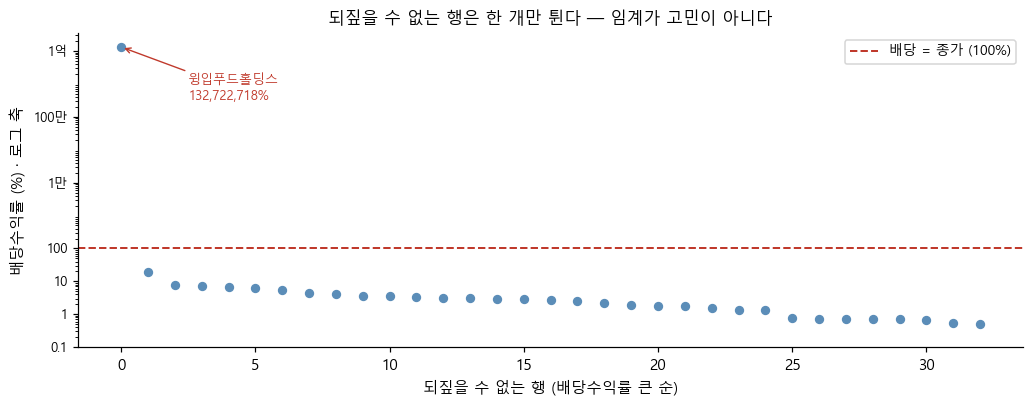

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
y = 셋["배당수익률%"].values
ax.scatter(range(len(y)), y, s=26, color="#5b8db8", zorder=3)
ax.set_yscale("log")
ax.axhline(100, color="#c0392b", lw=1.3, ls="--", label="배당 = 종가 (100%)")
ax.set_xlabel("되짚을 수 없는 행 (배당수익률 큰 순)")
ax.set_ylabel("배당수익률 (%) · 로그 축")
ax.set_title("되짚을 수 없는 행은 한 개만 튄다 — 임계가 고민이 아니다", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
# mathtext 의 U+2212 를 피해 눈금을 ASCII 로 다시 쓴다
ax.set_yticks([1e-1, 1e0, 1e1, 1e2, 1e4, 1e6, 1e8])
ax.set_yticklabels(["0.1", "1", "10", "100", "1만", "100만", "1억"], fontsize=8.5)
if len(y):
    ax.annotate(f"윙입푸드홀딩스\n{y[0]:,.0f}%", xy=(0, y[0]), xytext=(2.5, y[0] / 40),
                fontsize=8.5, color="#c0392b",
                arrowprops=dict(arrowstyle="->", color="#c0392b", lw=0.9))
plt.tight_layout()
plt.show()

## 7. 배당이 성과를 얼마나 올리나 — 종목별 누적

첫 유효 거래일부터 마지막까지, 두 축의 누적을 견줍니다.

In [16]:
첫 = pd.read_sql_query(
    "SELECT code, bas_dd, adj_close FROM daily_price WHERE adj_close IS NOT NULL", conn)
첫 = 첫.sort_values("bas_dd").groupby("code").first().reset_index()[["code", "adj_close"]]
끝 = pd.read_sql_query(
    "SELECT code, bas_dd, adj_close, adj_close_tr FROM daily_price "
    "WHERE adj_close_tr IS NOT NULL", conn)
끝 = 끝.sort_values("bas_dd").groupby("code").last().reset_index()
m = 첫.rename(columns={"adj_close": "a0"}).merge(
    끝[["code", "adj_close", "adj_close_tr"]].rename(
        columns={"adj_close": "a1", "adj_close_tr": "t1"}), on="code")
m = m[(m["a0"] > 0) & m["a1"].notna() & m["t1"].notna()].copy()
m["가격%"] = (m["a1"] / m["a0"] - 1) * 100
m["총수익%"] = (m["t1"] / m["a0"] - 1) * 100
m["차이%p"] = m["총수익%"] - m["가격%"]
print(f"종목 {len(m):,}개")
print(f"  가격 누적 중앙값   {m['가격%'].median():+8.2f}%")
print(f"  총수익 누적 중앙값 {m['총수익%'].median():+8.2f}%")
print(f"  차이 중앙값 {m['차이%p'].median():+.3f}%p · 평균 {m['차이%p'].mean():+.3f}%p")
같음 = int((m["차이%p"].abs() < 1e-6).sum())
음수 = int((m["차이%p"] < -1e-6).sum())
print(f"\n  차이가 0 인 종목 {같음:,} — 배당이 한 번도 없던 종목이다")
print(f"  차이가 음수인 종목 {음수:,} → "
      f"{'✅ 없다 (배당은 더하기만 하므로 당연하다)' if 음수 == 0 else '🔴 있다'}")
print()
print("배당 효과 상위 10")
이름 = pd.read_sql_query("SELECT DISTINCT code, name FROM daily_price", conn) \
    .drop_duplicates("code")
top = m.nlargest(10, "차이%p").merge(이름, on="code", how="left")
print(top[["code", "name", "가격%", "총수익%", "차이%p"]].to_string(
    index=False, float_format=lambda v: f"{v:+,.1f}"))

종목 3,677개
  가격 누적 중앙값     -28.81%
  총수익 누적 중앙값   -18.90%
  차이 중앙값 +0.399%p · 평균 +45.465%p

  차이가 0 인 종목 1,652 — 배당이 한 번도 없던 종목이다
  차이가 음수인 종목 0 → ✅ 없다 (배당은 더하기만 하므로 당연하다)

배당 효과 상위 10


  code      name       가격%      총수익%      차이%p
152550 한국ANKOR유전     +11.4 +21,825.4 +21,814.0
042700     한미반도체 +14,830.6 +22,715.7  +7,885.2
000155       두산우  +1,695.5  +4,252.7  +2,557.1
049720    고려신용정보  +1,419.0  +3,279.4  +1,860.4
095340       ISC  +5,265.3  +7,124.4  +1,859.1
000157     두산2우B  +1,187.5  +2,856.7  +1,669.1
058470      리노공업  +3,881.9  +5,497.9  +1,616.0
071055   한국금융지주우  +1,086.0  +2,579.9  +1,493.9
007660    이수페타시스  +5,285.1  +6,492.0  +1,206.9
000660      하이닉스  +6,924.9  +8,079.9  +1,155.0


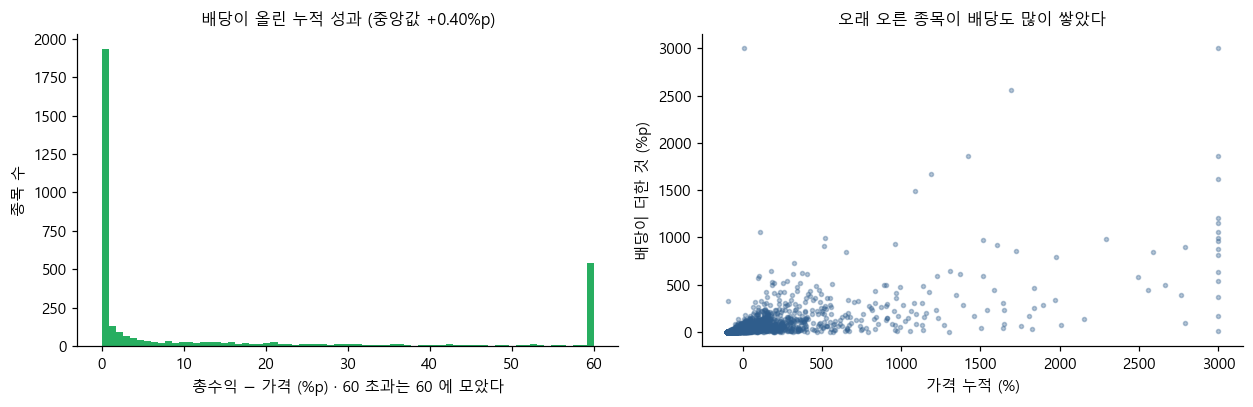

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]
값 = m["차이%p"].clip(upper=60)
ax.hist(값, bins=70, color="#27ae60", edgecolor="none")
ax.set_xlabel("총수익 − 가격 (%p) · 60 초과는 60 에 모았다")
ax.set_ylabel("종목 수")
ax.set_title(f"배당이 올린 누적 성과 (중앙값 {m['차이%p'].median():+.2f}%p)", fontsize=10.5)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
표본 = m[m["차이%p"] > 1e-6]
ax.scatter(표본["가격%"].clip(-100, 3000), 표본["차이%p"].clip(0, 3000),
           s=7, alpha=0.35, color="#2f5d8c")
ax.set_xlabel("가격 누적 (%)")
ax.set_ylabel("배당이 더한 것 (%p)")
ax.set_title("오래 오른 종목이 배당도 많이 쌓았다", fontsize=10.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8. 삼성전자 하나를 끝까지 따라가 본다

집계는 무엇이 벌어지는지를 가립니다. 한 종목의 두 축을 겹쳐 그립니다.

삼성전자 20100104 ~ 20260901 · 4,102행
  가격   16,180 → 261,000 (+1513.10%)
  총수익 16,180 → 356,416 (+2102.82%)
  배당이 얹힌 날 52회


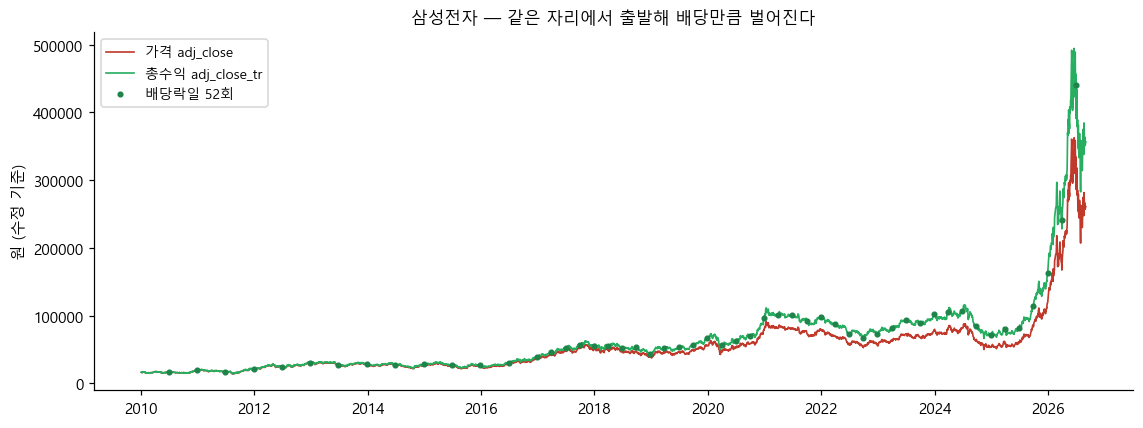

In [18]:
s = pd.read_sql_query("""
    SELECT bas_dd, adj_close, adj_close_tr, adj_dividend
    FROM daily_price WHERE code='005930' AND adj_close_tr IS NOT NULL
    ORDER BY bas_dd
""", conn)
s["날짜"] = pd.to_datetime(s["bas_dd"], format="%Y%m%d")
a0 = s["adj_close"].iloc[0]
print(f"삼성전자 {s['bas_dd'].iloc[0]} ~ {s['bas_dd'].iloc[-1]} · {len(s):,}행")
print(f"  가격   {a0:,.0f} → {s['adj_close'].iloc[-1]:,.0f} "
      f"({(s['adj_close'].iloc[-1] / a0 - 1) * 100:+.2f}%)")
print(f"  총수익 {a0:,.0f} → {s['adj_close_tr'].iloc[-1]:,.0f} "
      f"({(s['adj_close_tr'].iloc[-1] / a0 - 1) * 100:+.2f}%)")
print(f"  배당이 얹힌 날 {int(s['adj_dividend'].notna().sum())}회")

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.plot(s["날짜"], s["adj_close"], lw=1.1, color="#c0392b", label="가격 adj_close")
ax.plot(s["날짜"], s["adj_close_tr"], lw=1.1, color="#27ae60",
        label="총수익 adj_close_tr")
락 = s[s["adj_dividend"].notna()]
ax.scatter(락["날짜"], 락["adj_close_tr"], s=9, color="#1e8449", zorder=3,
           label=f"배당락일 {len(락)}회")
ax.set_ylabel("원 (수정 기준)")
ax.set_title("삼성전자 — 같은 자리에서 출발해 배당만큼 벌어진다", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 9. ⚠️ 제가 쓴 숫자가 한 번 틀렸습니다

이 작업을 하면서 코드 주석 여섯 곳에 배당락일 눌림을 **−0.455%p** 로 적었습니다.
그런데 그 값은 **배당 자료가 없던 때의 대용치**였습니다 —
*"KOSPI 시총 상위 100 · 연말 마지막 거래일 대비 위치"*.

| | 대용치 (v4.1) | 실제 배당락일 (v4.2) |
|---|---:|---:|
| 배당락일 효과 | −0.455%p | **−1.4665%p** |
| 음수인 해 | 15년 중 11년 | **17년 전부** |

**3.2배였습니다.** 대용치가 사건을 흐린 이유는 둘입니다.

- **연말만 봐서 분기배당을 놓쳤다** — 삼성전자는 연 4회 배당합니다
- **시총 상위 100 만 봐서 고배당 중소형주를 놓쳤다**

> **대용치는 크기를 줄이는 쪽으로 틀립니다.** 원자료가 생기면 다시 재야 합니다.

이 노트북의 §3 실측(−1.1465%p)은 또 조금 다릅니다 — 여기는 **전 종목 · 개발구간**
이고 v4.2 측정은 표본과 구간이 달랐습니다. 어느 쪽도 틀린 것이 아니라 **무엇을 재는지가
다릅니다.** 그래서 숫자를 옮길 때는 **측정 조건을 같이 옮겨야** 합니다.

In [19]:
print("=" * 66)
print("이 노트북이 남기는 것")
print("=" * 66)
줄 = [
    "① 배당기준일은 대부분 거래일이 아니다 (12월은 특히). 조인 축은 배당락일이다.",
    f"② 가격 축에서 배당락일은 눌려 있다 — 전 종목·개발구간 "
    f"{결과.iloc[0]['차이%p']:+.4f}%p, 연도별로 {가음}/{연도수} 해가 음수.",
    f"③ 총수익 축에서 그 눌림이 뒤집힌다 — {결과.iloc[1]['차이%p']:+.4f}%p, "
    f"음수인 해가 {총음}/{연도수} 로 줄었다. 이것이 이 작업의 검산이다.",
    f"④ 단위 오류는 크기로 자르면 안 된다 — 배당이 종가보다 큰 {len(큰것)}건 중 "
    f"{int((~큰것['의심']).sum())}건이 정당한 청산분배금이었다.",
    f"⑤ 원본이 자기 정합적인가로 가른다 — 되짚은 액면가가 붙는 행이 "
    f"{맞음 / 대상수 * 100:.2f}%. 되짚을 수 없는 {모름}행 중 1위와 2위의 간극이 "
    f"{역산불가[0] / 역산불가[1]:,.0f}배라 임계가 고민이 아니다.",
    f"⑥ 배당은 누적 성과를 종목 중앙값 {m['차이%p'].median():+.3f}%p 올린다. "
    "음수는 0건이다.",
    "⑦ 🔴 이 칸은 성과 축이지 피처가 아니다 — 배당 확정이 주주총회라 그 전에는",
    "   금액을 알 수 없어 입력으로 넣으면 미래참조가 된다.",
]
for 한줄 in 줄:
    print(한줄)
now = pd.Timestamp.now(tz="Asia/Seoul")
print()
print(f"총 {time.time() - t0:.1f}초 · {now:%Y-%m-%d %H:%M} KST")
conn.close()

이 노트북이 남기는 것
① 배당기준일은 대부분 거래일이 아니다 (12월은 특히). 조인 축은 배당락일이다.
② 가격 축에서 배당락일은 눌려 있다 — 전 종목·개발구간 -1.1465%p, 연도별로 11/15 해가 음수.
③ 총수익 축에서 그 눌림이 뒤집힌다 — +1.3235%p, 음수인 해가 1/15 로 줄었다. 이것이 이 작업의 검산이다.
④ 단위 오류는 크기로 자르면 안 된다 — 배당이 종가보다 큰 4건 중 3건이 정당한 청산분배금이었다.
⑤ 원본이 자기 정합적인가로 가른다 — 되짚은 액면가가 붙는 행이 99.29%. 되짚을 수 없는 33행 중 1위와 2위의 간극이 6,790,518배라 임계가 고민이 아니다.
⑥ 배당은 누적 성과를 종목 중앙값 +0.399%p 올린다. 음수는 0건이다.
⑦ 🔴 이 칸은 성과 축이지 피처가 아니다 — 배당 확정이 주주총회라 그 전에는
   금액을 알 수 없어 입력으로 넣으면 미래참조가 된다.

총 305.8초 · 2026-09-10 10:56 KST
